## Project Configuration

A shared configuration block was used across the whole project so that key settings such as file paths, image size, batch size, learning rate, number of epochs, and class labels were defined once and reused in all subtasks. This makes the notebook more consistent, easier to update, and more reproducible.

## Subtask 1: Baseline Models

For Subtask 1, two baseline models were developed: **FNN_base** and **CNN_base**. These models were trained only on the provided activity images, following the assignment requirement to compare a feedforward neural network and a convolutional neural network on the same classification task. :contentReference[oaicite:0]{index=0}

## Why the Baseline Accuracy Was Low

The results showed relatively low accuracy for both baseline models. This is expected because the dataset is challenging and the images differ in background, object position, scale, and overall appearance. Although the images were resized to a fixed input size before training, the original visual variation in the dataset still makes classification difficult, especially for simple baseline models. :contentReference[oaicite:1]{index=1}

## Interpretation of FNN_base and CNN_base

The **FNN_base** model uses flattened pixel values, so it does not preserve the spatial structure of the image. This limits its ability to learn meaningful visual patterns. The **CNN_base** model is more suitable for images because it learns local features through convolution layers, but in this baseline setup its performance was still limited by the small and visually varied dataset.

## Why Subtask 1 Is Still Important

Even though the baseline results were not strong, Subtask 1 is still important because it provides a reference point for the rest of the project. It shows the initial performance level before any improvements are applied and helps justify the need for more advanced methods in the next stage.

## Link to Subtask 2

The outcome of Subtask 1 motivates Subtask 2, where the CNN model will be improved using generalisation techniques such as augmentation, regularisation, and better training strategies. Therefore, the low baseline accuracy is not a failure, but a useful starting point for showing how later methods improve performance. :contentReference[oaicite:2]{index=2}

# **Create config.py**

In [ ]:
# ========================= CELL 0 =========================
%%writefile /content/config.py
# /content/config.py

import torch

CONFIG = {
    # ------------------- Project -------------------
    "project_name": "activity_recognition_project",
    "task_name": "human_activity_classification",
    "framework": "pytorch",

    # ------------------- Reproducibility -------------------
    "random_seed": 42,

    # ------------------- Paths -------------------
    "csv_path": "/content/image_url.csv",
    "img_dir": "/content/images",
    "models_dir": "/content/models",
    "outputs_dir": "/content/outputs",

    # ------------------- Dataset -------------------
    "image_col": "file_name",
    "label_col": "label",
    "class_names": ["sitting", "standing", "walking_running"],
    "num_classes": 3,

    # ------------------- Splits -------------------
    "val_split": 0.15,
    "test_split": 0.15,

    # ------------------- Image -------------------
    "image_size": (128, 128),
    "num_channels": 3,

    # ------------------- Training -------------------
    "batch_size": 16,
    "num_workers": 0,
    "epochs": 30,
    "learning_rate": 3e-4,
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    # ------------------- Download -------------------
    "download_missing_images": True,
    "download_timeout_seconds": 30,

    # ------------------- Subtask 1: FNN_base -------------------
    "fnn_hidden_units": [256, 128],

    # ------------------- Subtask 1: CNN_base -------------------
    "cnn_conv1_out_channels": 32,
    "cnn_conv2_out_channels": 64,
    "cnn_conv3_out_channels": 128,
    "cnn_kernel_size": 3,
    "cnn_padding": 1,
    "cnn_pool_kernel_size": 2,
    "cnn_linear_units": 256,

    # ------------------- Subtask 2 defaults -------------------
    "weight_decay": 0.0,
    "early_stopping_patience": 5,
    "scheduler_patience": 3,
    "lr_factor": 0.5,
    "lr_min": 1e-5,
    "dropout_rate": 0.0,

    "cnn_conv_channels": [32, 64, 128],
    "aug_rotation_degrees": 0,
    "aug_horizontal_flip_prob": 0.0,
    "aug_color_jitter_brightness": 0.0,
    "aug_color_jitter_contrast": 0.0,
}

# **Create subtask1.py**

In [ ]:
# /content/subtask1.py

from __future__ import annotations

import copy
import json
import os
import random
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def ensure_dir(path: str | Path) -> Path:
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def save_json(data: dict[str, Any], path: str | Path) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)


class ActivityDataset(Dataset):
    def __init__(
        self,
        dataframe: pd.DataFrame,
        image_col: str,
        label_index_col: str,
        transform: transforms.Compose,
    ) -> None:
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_col = image_col
        self.label_index_col = label_index_col
        self.transform = transform

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, idx: int):
        row = self.dataframe.iloc[idx]
        image_path = row[self.image_col]
        label = int(row[self.label_index_col])

        image = Image.open(image_path).convert("RGB")
        image_tensor = self.transform(image)
        label_tensor = torch.tensor(label, dtype=torch.long)
        return image_tensor, label_tensor


class FNNBase(nn.Module):
    def __init__(
        self,
        input_height: int,
        input_width: int,
        input_channels: int,
        hidden_units: list[int],
        num_classes: int,
    ) -> None:
        super().__init__()
        input_dim = input_height * input_width * input_channels
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_units[0]),
            nn.ReLU(),
            nn.Linear(hidden_units[0], hidden_units[1]),
            nn.ReLU(),
            nn.Linear(hidden_units[1], num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


class CNNBase(nn.Module):
    def __init__(
        self,
        input_channels: int,
        conv1_out_channels: int,
        conv2_out_channels: int,
        conv3_out_channels: int,
        kernel_size: int,
        padding: int,
        pool_kernel_size: int,
        linear_units: int,
        num_classes: int,
    ) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, conv1_out_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm2d(conv1_out_channels),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=pool_kernel_size),

            nn.Conv2d(conv1_out_channels, conv2_out_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm2d(conv2_out_channels),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=pool_kernel_size),

            nn.Conv2d(conv2_out_channels, conv3_out_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm2d(conv3_out_channels),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=pool_kernel_size),

            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv3_out_channels, linear_units),
            nn.ReLU(),
            nn.Linear(linear_units, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(x)


def validate_config(config: dict[str, Any]) -> None:
    required = [
        "csv_path",
        "img_dir",
        "models_dir",
        "outputs_dir",
        "image_col",
        "label_col",
        "class_names",
        "num_classes",
        "random_seed",
        "val_split",
        "test_split",
        "image_size",
        "num_channels",
        "batch_size",
        "epochs",
        "learning_rate",
        "device",
        "num_workers",
        "fnn_hidden_units",
        "cnn_conv1_out_channels",
        "cnn_conv2_out_channels",
        "cnn_conv3_out_channels",
        "cnn_kernel_size",
        "cnn_padding",
        "cnn_pool_kernel_size",
        "cnn_linear_units",
    ]
    missing = [k for k in required if k not in config]
    if missing:
        raise ValueError(f"Missing config keys: {missing}")


def load_dataframe(config: dict[str, Any]) -> pd.DataFrame:
    df = pd.read_csv(config["csv_path"]).copy()
    df = df[[config["image_col"], "coco_url", config["label_col"]]].dropna().copy()
    df[config["image_col"]] = df[config["image_col"]].astype(str).str.strip()
    df[config["label_col"]] = df[config["label_col"]].astype(str).str.strip()

    label_to_index = {label: idx for idx, label in enumerate(config["class_names"])}
    df["label_idx"] = df[config["label_col"]].map(label_to_index)

    if df["label_idx"].isna().any():
        bad = df[df["label_idx"].isna()][config["label_col"]].unique().tolist()
        raise ValueError(f"Unexpected labels found: {bad}")

    df["label_idx"] = df["label_idx"].astype(int)
    df["image_path"] = df[config["image_col"]].apply(
        lambda x: str(Path(config["img_dir"]) / x)
    )
    return df


def download_missing_images(
    df: pd.DataFrame,
    image_path_col: str,
    url_col: str,
    timeout_seconds: int = 30,
) -> None:
    missing_df = df[~df[image_path_col].map(os.path.exists)].copy()
    if missing_df.empty:
        print("All images already exist.")
        return

    print(f"Downloading {len(missing_df)} missing images...")
    session = requests.Session()

    for _, row in missing_df.iterrows():
        image_path = Path(row[image_path_col])
        image_path.parent.mkdir(parents=True, exist_ok=True)
        try:
            response = session.get(row[url_col], timeout=timeout_seconds)
            response.raise_for_status()
            with open(image_path, "wb") as f:
                f.write(response.content)
        except Exception as exc:
            print(f"Download failed for {image_path.name}: {exc}")


def filter_existing_images(df: pd.DataFrame, image_path_col: str) -> pd.DataFrame:
    filtered = df[df[image_path_col].map(os.path.exists)].copy().reset_index(drop=True)
    if filtered.empty:
        raise ValueError("No images found after filtering existing files.")
    return filtered


def make_splits(df: pd.DataFrame, config: dict[str, Any]):
    train_df, temp_df = train_test_split(
        df,
        test_size=(config["val_split"] + config["test_split"]),
        random_state=config["random_seed"],
        stratify=df["label_idx"],
    )

    rel_test = config["test_split"] / (config["val_split"] + config["test_split"])

    val_df, test_df = train_test_split(
        temp_df,
        test_size=rel_test,
        random_state=config["random_seed"],
        stratify=temp_df["label_idx"],
    )

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


def build_transform(config: dict[str, Any]) -> transforms.Compose:
    return transforms.Compose(
        [
            transforms.Resize(config["image_size"]),
            transforms.ToTensor(),
        ]
    )


def build_dataloaders(train_df, val_df, test_df, config: dict[str, Any]):
    transform = build_transform(config)

    train_ds = ActivityDataset(train_df, "image_path", "label_idx", transform)
    val_ds = ActivityDataset(val_df, "image_path", "label_idx", transform)
    test_ds = ActivityDataset(test_df, "image_path", "label_idx", transform)

    train_loader = DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=config["num_workers"],
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
    )

    return train_loader, val_loader, test_loader


def build_model(model_name: str, config: dict[str, Any]) -> nn.Module:
    if model_name == "FNN_base":
        return FNNBase(
            input_height=config["image_size"][0],
            input_width=config["image_size"][1],
            input_channels=config["num_channels"],
            hidden_units=config["fnn_hidden_units"],
            num_classes=config["num_classes"],
        )

    if model_name == "CNN_base":
        return CNNBase(
            input_channels=config["num_channels"],
            conv1_out_channels=config["cnn_conv1_out_channels"],
            conv2_out_channels=config["cnn_conv2_out_channels"],
            conv3_out_channels=config["cnn_conv3_out_channels"],
            kernel_size=config["cnn_kernel_size"],
            padding=config["cnn_padding"],
            pool_kernel_size=config["cnn_pool_kernel_size"],
            linear_units=config["cnn_linear_units"],
            num_classes=config["num_classes"],
        )

    raise ValueError(f"Unknown model name: {model_name}")


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        # --- START DEBUG PRINT --- #
        if not isinstance(logits, torch.Tensor):
            print(f"DEBUG: Type of logits from model(images): {type(logits)}")
            if hasattr(logits, 'logits'):
                print(f"DEBUG: logits object has 'logits' attribute. Type: {type(logits.logits)}")
            elif isinstance(logits, dict) and 'logits' in logits:
                print(f"DEBUG: logits object has 'logits' key (dict). Type: {type(logits['logits'])}")
        # --- END DEBUG PRINT --- #
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_count += labels.size(0)

    return total_loss / total_count, total_correct / total_count


@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    y_true = []
    y_pred = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)

        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total_count += labels.size(0)

        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())

    return total_loss / total_count, total_correct / total_count, y_true, y_pred


@torch.no_grad()
def collect_predictions_and_images(model, loader, device):
    model.eval()
    all_images = []
    all_true = []
    all_pred = []

    for images, labels in loader:
        logits = model(images.to(device))
        preds = logits.argmax(dim=1).cpu()

        all_images.append(images.cpu())
        all_true.extend(labels.numpy().tolist())
        all_pred.extend(preds.numpy().tolist())

    return torch.cat(all_images, dim=0), all_true, all_pred


def compute_metrics(y_true, y_pred, class_names):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "classification_report": classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0,
            output_dict=True,
        ),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }


def plot_class_distribution(df, config, save_path):
    counts = df[config["label_col"]].value_counts().reindex(config["class_names"])
    plt.figure(figsize=(7, 4))
    plt.bar(counts.index, counts.values)
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_sample_images(df, config, save_path, n_per_class=3):
    rows = len(config["class_names"])
    cols = n_per_class
    plt.figure(figsize=(12, 8))
    plot_idx = 1

    for class_name in config["class_names"]:
        subset = df[df[config["label_col"]] == class_name].head(n_per_class)
        for _, row in subset.iterrows():
            image = Image.open(row["image_path"]).convert("RGB")
            plt.subplot(rows, cols, plot_idx)
            plt.imshow(image)
            plt.title(class_name)
            plt.axis("off")
            plot_idx += 1

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_history(history, model_name, save_path):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_confusion(cm, class_names, title, save_path):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_misclassified_examples(images, y_true, y_pred, class_names, title, save_path, max_items=9):
    wrong_idx = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if t != p][:max_items]

    if not wrong_idx:
        print(f"{title}: no misclassified examples to plot.")
        return

    plt.figure(figsize=(12, 8))
    for plot_i, idx in enumerate(wrong_idx, start=1):
        image = images[idx].permute(1, 2, 0).numpy()
        image = np.clip(image, 0, 1)
        plt.subplot(3, 3, plot_i)
        plt.imshow(image)
        plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def train_model(model_name, config, train_loader, val_loader, test_loader):
    device = config["device"]
    model = build_model(model_name, config).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = -1.0

    for epoch in range(1, config["epochs"] + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate_one_epoch(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"{model_name} | Epoch {epoch:02d}/{config['epochs']:02d} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    _, _, val_true, val_pred = evaluate_one_epoch(model, val_loader, criterion, device)
    _, _, test_true, test_pred = evaluate_one_epoch(model, test_loader, criterion, device)

    val_metrics = compute_metrics(val_true, val_pred, config["class_names"])
    test_metrics = compute_metrics(test_true, test_pred, config["class_names"])

    outputs_dir = ensure_dir(config["outputs_dir"])
    models_dir = ensure_dir(config["models_dir"])

    plot_history(history, model_name, outputs_dir / f"{model_name}_history.png")
    plot_confusion(
        val_metrics["confusion_matrix"],
        config["class_names"],
        f"{model_name} Validation Confusion Matrix",
        outputs_dir / f"{model_name}_val_confusion.png",
    )
    plot_confusion(
        test_metrics["confusion_matrix"],
        config["class_names"],
        f"{model_name} Test Confusion Matrix",
        outputs_dir / f"{model_name}_test_confusion.png",
    )

    test_images, test_true_list, test_pred_list = collect_predictions_and_images(model, test_loader, device)
    plot_misclassified_examples(
        test_images,
        test_true_list,
        test_pred_list,
        config["class_names"],
        f"{model_name} Misclassified Test Images",
        outputs_dir / f"{model_name}_misclassified.png",
    )

    torch.save(model.state_dict(), models_dir / f"{model_name}.pt")
    pd.DataFrame(val_metrics["classification_report"]).transpose().to_csv(
        outputs_dir / f"{model_name}_val_report.csv"
    )
    pd.DataFrame(test_metrics["classification_report"]).transpose().to_csv(
        outputs_dir / f"{model_name}_test_report.csv"
    )

    return {
        "model_name": model_name,
        "history": history,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
    }


def run_subtask1(config: dict[str, Any]):
    validate_config(config)
    set_seed(config["random_seed"])
    ensure_dir(config["img_dir"])
    ensure_dir(config["models_dir"])
    ensure_dir(config["outputs_dir"])

    df = load_dataframe(config)

    if config.get("download_missing_images", True):
        download_missing_images(df, "image_path", "coco_url", config.get("download_timeout_seconds", 30))

    df = filter_existing_images(df, "image_path")

    print("Usable images:", len(df))
    print(df[config["label_col"]].value_counts())

    if len(df) < 250:
        print("Warning: usable image count is low. Accuracy may be poor because many downloads failed.")

    outputs_dir = ensure_dir(config["outputs_dir"])
    plot_class_distribution(df, config, outputs_dir / "class_distribution.png")
    plot_sample_images(df, config, outputs_dir / "sample_images.png", n_per_class=3)

    train_df, val_df, test_df = make_splits(df, config)
    print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

    train_loader, val_loader, test_loader = build_dataloaders(train_df, val_df, test_df, config)

    fnn_results = train_model("FNN_base", config, train_loader, val_loader, test_loader)
    cnn_results = train_model("CNN_base", config, train_loader, val_loader, test_loader)

    comparison_df = pd.DataFrame(
        [
            {
                "model": fnn_results["model_name"],
                "val_accuracy": fnn_results["val_metrics"]["accuracy"],
                "val_macro_f1": fnn_results["val_metrics"]["macro_f1"],
                "test_accuracy": fnn_results["test_metrics"]["accuracy"],
                "test_macro_f1": fnn_results["test_metrics"]["macro_f1"],
            },
            {
                "model": cnn_results["model_name"],
                "val_accuracy": cnn_results["val_metrics"]["accuracy"],
                "val_macro_f1": cnn_results["val_metrics"]["macro_f1"],
                "test_accuracy": cnn_results["test_metrics"]["accuracy"],
                "test_macro_f1": cnn_results["test_metrics"]["macro_f1"],
            },
        ]
    ).sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)

    comparison_df.to_csv(outputs_dir / "subtask1_model_comparison.csv", index=False)
    save_json(
        {
            "usable_images": int(len(df)),
            "train_size": int(len(train_df)),
            "val_size": int(len(val_df)),
            "test_size": int(len(test_df)),
        },
        outputs_dir / "subtask1_summary.json",
    )

    print("\nFinal comparison")
    print(comparison_df)
    return comparison_df


# ===============================================================
# +--------------------[ START:PROJECT CONFIGURATION ]--------------------- +
# ===============================================================

In [ ]:
import importlib
import subtask1
import config

importlib.reload(config)
importlib.reload(subtask1)

CONFIG = config.CONFIG.copy()

comparison_df_subtask1 = subtask1.run_subtask1(CONFIG)
comparison_df_subtask1

# ===============================================================
# +--------------------[ START:PROJECT CONFIGURATION ]--------------------- +
# ===============================================================

In [ ]:
comparison_df = subtask1.run_subtask1(CONFIG)
comparison_df


# ========================= CELL 3 =========================
import os
print("Models:", os.listdir("/content/models"))
print("Outputs:", os.listdir("/content/outputs"))

## Subtask 2: CNN\_gen for improved generalisation

In this subtask, the baseline CNN model from Subtask 1 was improved to create **CNN\_gen**. The purpose of this stage was to improve model generalisation rather than only memorising the training images.

### Why these techniques were used

Several generalisation methods were applied. First, **data augmentation** was used to create varied versions of the training images, helping the model learn features that are less sensitive to small visual changes. Second, **dropout** was added to reduce over-reliance on specific neurons during training. Third, **weight decay** was used to penalise overly large weights and reduce overfitting. Finally, **early stopping** and a **learning-rate scheduler** were used so that training could stop or slow down when validation performance stopped improving.

### Why CNN\_gen is different from CNN\_base

The original **CNN\_base** from Subtask 1 was a simple baseline model. In contrast, **CNN\_gen** is designed specifically to improve performance on unseen data. This makes it more suitable for the assignment requirement of testing techniques that improve generalisation.

### Expected outcome

Subtask 2 should produce a better-performing CNN than the baseline in Subtask 1. Even if the improvement is moderate, the comparison is still valuable because it shows whether augmentation and regularisation help on this dataset.

# **Offline augmentation**

This means you actually save new augmented images into a folder until you reach, for example, 1000 images.

So yes, you can do that if you want:

read original image
apply random transforms
save as new file
update CSV or create new dataframe
stop when total count reaches 1000

In [ ]:
import os
import random
from pathlib import Path

import pandas as pd
from PIL import Image
from torchvision import transforms

TARGET_TOTAL = 1000
CSV_PATH = "/content/image_url.csv"
IMG_DIR = Path("/content/images")
AUG_DIR = Path("/content/images_augmented")
AUG_CSV_PATH = "/content/image_url_augmented.csv"

AUG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV_PATH).copy()
df["image_path"] = df["file_name"].apply(lambda x: str(IMG_DIR / x))

df = df[df["image_path"].apply(os.path.exists)].reset_index(drop=True)

augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

new_rows = []
current_total = len(df)
needed = max(0, TARGET_TOTAL - current_total)

for i in range(needed):
    row = df.sample(1, random_state=None).iloc[0]
    original_path = row["image_path"]
    original_name = Path(row["file_name"]).stem
    original_ext = Path(row["file_name"]).suffix

    image = Image.open(original_path).convert("RGB")
    aug_image = augmentation(image)

    new_name = f"{original_name}_aug_{i:04d}{original_ext}"
    new_path = AUG_DIR / new_name
    aug_image.save(new_path)

    new_rows.append({
        "file_name": new_name,
        "coco_url": row["coco_url"],
        "label": row["label"],
    })

aug_df = pd.DataFrame(new_rows)
final_df = pd.concat([df[["file_name", "coco_url", "label"]], aug_df], ignore_index=True)
final_df.to_csv(AUG_CSV_PATH, index=False)

print("Original images:", len(df))
print("Augmented images created:", len(aug_df))
print("Final total images:", len(final_df))
print("Saved CSV:", AUG_CSV_PATH)

# **Data augmentation** was used to increase the diversity of the training data rather than to physically create a new fixed dataset on disk. Although the number of stored image files remained unchanged, the model was exposed to many transformed variants of the original images during training.

# **Create subtask2.py**

### Subtask 2: CNN_gen with Generalization Techniques

In Subtask 2, the baseline CNN from Subtask 1 was improved to create **CNN_gen**. The purpose of this stage was to improve generalization so that the model performs better on unseen images rather than only fitting the training data.

To achieve this, several generalization techniques were applied. First, **data augmentation** was used to generate varied versions of the training images, which helps the model become less sensitive to small changes in appearance. Second, **dropout** was introduced to reduce over-reliance on individual neurons. Third, **weight decay** was applied to discourage overly complex weights and reduce overfitting. Fourth, **early stopping** was used so that training stops when validation performance no longer improves. A learning-rate scheduler was also used to stabilise training.

The resulting model is reported as **CNN_gen**, and its performance is compared against **CNN_base** from Subtask 1. This allows the effect of the generalization techniques to be measured clearly.

In [ ]:
# ========================= CELL 4 =========================
# %%writefile /content/subtask2.py
# /content/subtask2.py

from __future__ import annotations

import copy
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import transforms

from subtask1 import (
    ActivityDataset,
    collect_predictions_and_images,
    compute_metrics,
    download_missing_images,
    ensure_dir,
    evaluate_one_epoch,
    filter_existing_images,
    load_dataframe,
    make_splits,
    plot_class_distribution,
    plot_confusion,
    plot_sample_images,
    save_json,
    set_seed,
    train_one_epoch,
    validate_config as validate_subtask1_config,
)


class EarlyStopping:
    def __init__(self, patience: int, min_delta: float = 0.0) -> None:
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, score: float) -> bool:
        if self.best_score is None or score > (self.best_score + self.min_delta):
            self.best_score = score
            self.counter = 0
            return False

        self.counter += 1
        if self.counter >= self.patience:
            self.should_stop = True
        return self.should_stop


class CNNGen(nn.Module):
    def __init__(
        self,
        input_channels: int,
        conv_channels: list[int],
        kernel_size: int,
        padding: int,
        pool_kernel_size: int,
        linear_units: int,
        dropout_rate: float,
        num_classes: int,
    ) -> None:
        super().__init__()

        blocks: list[nn.Module] = []
        in_channels = input_channels

        for out_channels in conv_channels:
            blocks.extend(
                [
                    nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding),
                    nn.BatchNorm2d(out_channels),
                    nn.ReLU(),
                    nn.MaxPool2d(kernel_size=pool_kernel_size),
                    nn.Dropout2d(p=dropout_rate),
                ]
            )
            in_channels = out_channels

        blocks.append(nn.AdaptiveAvgPool2d((2, 2)))
        self.features = nn.Sequential(*blocks)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv_channels[-1] * 2 * 2, linear_units),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(linear_units, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return self.classifier(x)


def validate_config(config: dict[str, Any]) -> None:
    validate_subtask1_config(config)

    required_extra = [
        "weight_decay",
        "early_stopping_patience",
        "scheduler_patience",
        "lr_factor",
        "lr_min",
        "dropout_rate",
        "cnn_conv_channels",
        "aug_rotation_degrees",
        "aug_horizontal_flip_prob",
        "aug_color_jitter_brightness",
        "aug_color_jitter_contrast",
    ]
    missing = [key for key in required_extra if key not in config]
    if missing:
        raise ValueError(f"Missing subtask2 config keys: {missing}")

# start: Data Augmentation
def build_transforms(config: dict[str, Any]):
    train_transform = transforms.Compose(
        [
            transforms.Resize(config["image_size"]),
            transforms.RandomHorizontalFlip(p=config["aug_horizontal_flip_prob"]),
            transforms.RandomRotation(degrees=config["aug_rotation_degrees"]),
            transforms.ColorJitter(
                brightness=config["aug_color_jitter_brightness"],
                contrast=config["aug_color_jitter_contrast"],
            ),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ]
    )

    eval_transform = transforms.Compose(
        [
            transforms.Resize(config["image_size"]),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ]
    )

    viz_transform = transforms.Compose(
        [
            transforms.Resize(config["image_size"]),
            transforms.RandomHorizontalFlip(p=config["aug_horizontal_flip_prob"]),
            transforms.RandomRotation(degrees=config["aug_rotation_degrees"]),
            transforms.ColorJitter(
                brightness=config["aug_color_jitter_brightness"],
                contrast=config["aug_color_jitter_contrast"],
            ),
        ]
    )
# End data Augmentations
    return train_transform, eval_transform, viz_transform


def build_dataloaders(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    config: dict[str, Any],
):
    train_transform, eval_transform, _ = build_transforms(config)

    train_ds = ActivityDataset(train_df, "image_path", "label_idx", train_transform)
    val_ds = ActivityDataset(val_df, "image_path", "label_idx", eval_transform)
    test_ds = ActivityDataset(test_df, "image_path", "label_idx", eval_transform)

    train_loader = DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=config["num_workers"],
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
    )

    return train_loader, val_loader, test_loader


def denormalize_image(image_tensor: torch.Tensor) -> np.ndarray:
    image = image_tensor.detach().cpu().numpy()
    image = np.transpose(image, (1, 2, 0))
    image = (image * 0.5) + 0.5
    return np.clip(image, 0.0, 1.0)


def plot_augmentation_examples(
    df: pd.DataFrame,
    config: dict[str, Any],
    save_path: str | Path,
    n_versions: int = 6,
) -> None:
    _, _, viz_transform = build_transforms(config)
    original = Image.open(df.iloc[0]["image_path"]).convert("RGB")

    plt.figure(figsize=(14, 5))
    plt.subplot(2, 4, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    for idx in range(1, n_versions + 1):
        aug_img = viz_transform(original)
        plt.subplot(2, 4, idx + 1)
        plt.imshow(aug_img)
        plt.title(f"Aug {idx}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_history(history: dict[str, list[float]], save_path: str | Path) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title("CNN_gen Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.title("CNN_gen Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["val_macro_f1"], label="Val Macro-F1")
    plt.title("CNN_gen Val Macro-F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_misclassified_examples(
    images: torch.Tensor,
    y_true: list[int],
    y_pred: list[int],
    class_names: list[str],
    title: str,
    save_path: str | Path,
    max_items: int = 9,
) -> None:
    wrong_idx = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if t != p][:max_items]

    if not wrong_idx:
        print(f"{title}: no misclassified examples.")
        return

    plt.figure(figsize=(12, 8))
    for plot_i, idx in enumerate(wrong_idx, start=1):
        image = denormalize_image(images[idx])
        plt.subplot(3, 3, plot_i)
        plt.imshow(image)
        plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def build_model(config: dict[str, Any]) -> nn.Module:
    return CNNGen(
        input_channels=config["num_channels"],
        conv_channels=config["cnn_conv_channels"],
        kernel_size=config["cnn_kernel_size"],
        padding=config["cnn_padding"],
        pool_kernel_size=config["cnn_pool_kernel_size"],
        linear_units=config["cnn_linear_units"],
        dropout_rate=config["dropout_rate"],
        num_classes=config["num_classes"],
    )


def train_model(
    config: dict[str, Any],
    train_loader,
    val_loader,
    test_loader,
) -> dict[str, Any]:
    device = config["device"]
    model = build_model(config).to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=config["lr_factor"],
        patience=config["scheduler_patience"],
        min_lr=config["lr_min"],
    )

    early_stopper = EarlyStopping(patience=config["early_stopping_patience"])

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_macro_f1": [],
    }

    best_state = copy.deepcopy(model.state_dict())
    best_val_macro_f1 = -1.0

    for epoch in range(1, config["epochs"] + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_true, val_pred = evaluate_one_epoch(model, val_loader, criterion, device)
        val_metrics = compute_metrics(val_true, val_pred, config["class_names"])
        val_macro_f1 = val_metrics["macro_f1"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_macro_f1)

        print(
            f"CNN_gen | Epoch {epoch:02d}/{config['epochs']:02d} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_macro_f1={val_macro_f1:.4f}"
        )

        scheduler.step(val_macro_f1)

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_state = copy.deepcopy(model.state_dict())

        if early_stopper.step(val_macro_f1):
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_state)

    _, _, val_true, val_pred = evaluate_one_epoch(model, val_loader, criterion, device)
    _, _, test_true, test_pred = evaluate_one_epoch(model, test_loader, criterion, device)

    val_metrics = compute_metrics(val_true, val_pred, config["class_names"])
    test_metrics = compute_metrics(test_true, test_pred, config["class_names"])

    outputs_dir = ensure_dir(config["outputs_dir"])
    models_dir = ensure_dir(config["models_dir"])

    plot_history(history, outputs_dir / "CNN_gen_history.png")
    plot_confusion(
        np.array(val_metrics["confusion_matrix"]),
        config["class_names"],
        "CNN_gen Validation Confusion Matrix",
        outputs_dir / "CNN_gen_val_confusion.png",
    )
    plot_confusion(
        np.array(test_metrics["confusion_matrix"]),
        config["class_names"],
        "CNN_gen Test Confusion Matrix",
        outputs_dir / "CNN_gen_test_confusion.png",
    )

    test_images, test_true_list, test_pred_list = collect_predictions_and_images(model, test_loader, device)
    plot_misclassified_examples(
        test_images,
        test_true_list,
        test_pred_list,
        config["class_names"],
        "CNN_gen Misclassified Test Images",
        outputs_dir / "CNN_gen_misclassified.png",
    )

    torch.save(model.state_dict(), models_dir / "CNN_gen.pt")
    pd.DataFrame(val_metrics["classification_report"]).transpose().to_csv(
        outputs_dir / "CNN_gen_val_report.csv"
    )
    pd.DataFrame(test_metrics["classification_report"]).transpose().to_csv(
        outputs_dir / "CNN_gen_test_report.csv"
    )

    return {
        "model_name": "CNN_gen",
        "history": history,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
    }


def run_subtask2(config: dict[str, Any]) -> pd.DataFrame:
    validate_config(config)
    set_seed(config["random_seed"])
    ensure_dir(config["img_dir"])
    ensure_dir(config["models_dir"])
    ensure_dir(config["outputs_dir"])

    df = load_dataframe(config)

    if config.get("download_missing_images", True):
        download_missing_images(
            df=df,
            image_path_col="image_path",
            url_col="coco_url",
            timeout_seconds=config.get("download_timeout_seconds", 30),
        )

    df = filter_existing_images(df, "image_path")

    print("Usable images:", len(df))
    print(df[config["label_col"]].value_counts().reindex(config["class_names"]))

    outputs_dir = ensure_dir(config["outputs_dir"])
    plot_class_distribution(df, config, outputs_dir / "subtask2_class_distribution.png")
    plot_sample_images(df, config, outputs_dir / "subtask2_sample_images.png", n_per_class=3)
    plot_augmentation_examples(df, config, outputs_dir / "subtask2_augmentation_examples.png", n_versions=6)

    train_df, val_df, test_df = make_splits(df, config)
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    train_loader, val_loader, test_loader = build_dataloaders(train_df, val_df, test_df, config)
    cnn_gen_results = train_model(config, train_loader, val_loader, test_loader)

    comparison_rows = []
    baseline_path = Path(config["outputs_dir"]) / "subtask1_model_comparison.csv"
    if baseline_path.exists():
        baseline_df = pd.read_csv(baseline_path)
        if "CNN_base" in baseline_df["model"].values:
            comparison_rows.append(
                baseline_df[baseline_df["model"] == "CNN_base"].iloc[0].to_dict()
            )

    comparison_rows.append(
        {
            "model": "CNN_gen",
            "val_accuracy": cnn_gen_results["val_metrics"]["accuracy"],
            "val_macro_f1": cnn_gen_results["val_metrics"]["macro_f1"],
            "test_accuracy": cnn_gen_results["test_metrics"]["accuracy"],
            "test_macro_f1": cnn_gen_results["test_metrics"]["macro_f1"],
        }
    )

    comparison_df = pd.DataFrame(comparison_rows)
    comparison_df.to_csv(outputs_dir / "subtask2_model_comparison.csv", index=False)

    save_json(
        {
            "usable_images": int(len(df)),
            "train_size": int(len(train_df)),
            "val_size": int(len(val_df)),
            "test_size": int(len(test_df)),
        },
        outputs_dir / "subtask2_summary.json",
    )

    print("\nFinal comparison")
    print(comparison_df)

    return comparison_df


Usable images: 1000
label
sitting            342
standing           309
walking_running    349
Name: count, dtype: int64


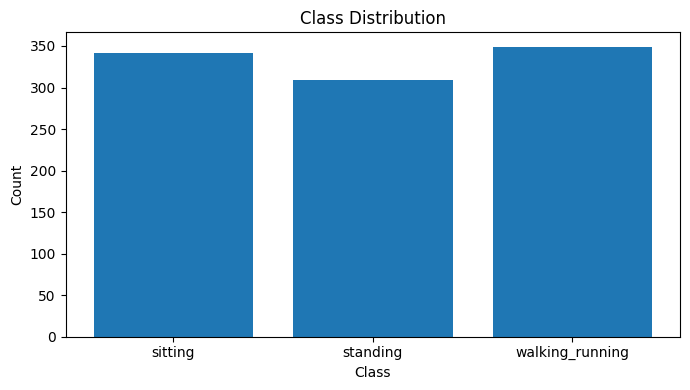

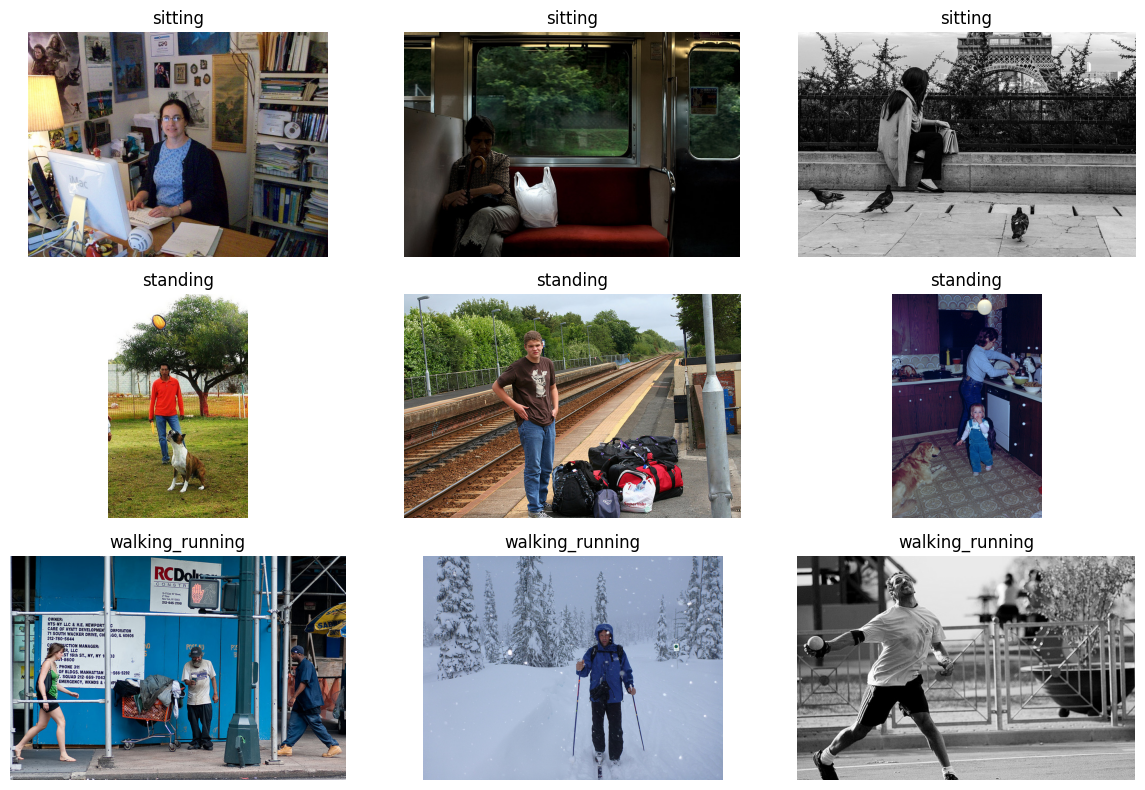

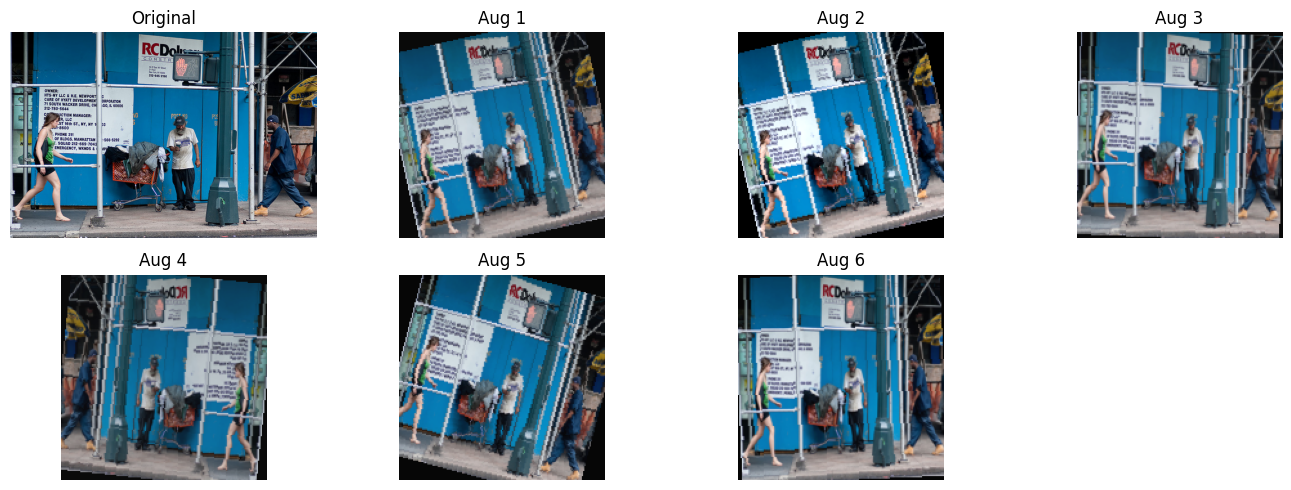

Train: 700 | Val: 150 | Test: 150


In [ ]:
# ========================= CELL 5 =========================
import importlib
import subtask2
import config

importlib.reload(config)
importlib.reload(subtask2)

CONFIG = config.CONFIG.copy()
CONFIG.update({
    "project_name": "subtask2_cnn_gen",
    "image_size": (160, 160),
    "epochs": 40,
    "learning_rate": 1e-3,

    "weight_decay": 5e-4,
    "early_stopping_patience": 6,
    "scheduler_patience": 3,
    "lr_factor": 0.5,
    "lr_min": 1e-5,
    "dropout_rate": 0.3,

    "cnn_conv_channels": [32, 64, 128, 128],
    "aug_rotation_degrees": 15,
    "aug_horizontal_flip_prob": 0.5,
    "aug_color_jitter_brightness": 0.2,
    "aug_color_jitter_contrast": 0.2,

    "csv_path": "/content/image_url_augmented.csv",
    "img_dir": "/content/images_augmented",
})

comparison_df_subtask2 = subtask2.run_subtask2(CONFIG)
comparison_df_subtask2




## **val_macro_f1 means:**

val = validation set
macro = calculate F1 for each class separately, then take the average
f1 = balance between precision and recall

So val_macro_f1 is:

the average F1 score across all classes on the validation set

Why it matters:

accuracy can look okay even if one class is predicted badly
macro F1 gives equal importance to every class
this is useful when you want a fair view across sitting, standing, and walking_running

Simple idea:

If class scores are:

sitting = 0.60
standing = 0.40
walking_running = 0.50

then:

val_macro_f1 = (0.60 + 0.40 + 0.50) / 3 = 0.50

Why use it in your project:

your model should not only be good on the easiest class
val_macro_f1 helps choose the model that is more balanced across all classes

In your code:

val_accuracy = how many validation images were predicted correctly overall
val_macro_f1 = how balanced the model is across all activity classes

Good report sentence:

The validation macro-F1 score was used in addition to accuracy because it gives equal importance to each class and provides a better measure of balanced classification performance across all activity labels.

## Precision, Recall, F1, and Macro-F1 in this Project

In this project, the model predicts one of three activity classes: **sitting**, **standing**, or **walking_running**. To understand model performance more clearly, accuracy alone is not enough, so precision, recall, F1, and macro-F1 are also used.

### Precision

**Precision** measures how many predictions for a class were actually correct.

For example, if the model predicts **standing** 10 times, but only 7 of those images are truly **standing**, then the precision for the **standing** class is:

\[
\text{Precision} = \frac{7}{10} = 0.70
\]

This tells us that when the model says an image is **standing**, it is correct 70% of the time.

### Recall

**Recall** measures how many true examples of a class were successfully found by the model.

For example, if there are 12 real **standing** images in the validation set, but the model correctly identifies only 7 of them, then the recall for the **standing** class is:

\[
\text{Recall} = \frac{7}{12} \approx 0.58
\]

This means the model found about 58% of all real **standing** images.

### F1 Score

The **F1 score** combines precision and recall into a single value. It is useful because it balances both types of performance.

If precision is high but recall is low, or recall is high but precision is low, the F1 score will reflect that imbalance. A model only gets a good F1 score when both precision and recall are reasonably strong.

### Macro-F1

Because this project has three classes, the F1 score can be calculated separately for **sitting**, **standing**, and **walking_running**, and then averaged. This is called **macro-F1**.

For example, if the class F1 scores are:

- **sitting** = 0.60  
- **standing** = 0.45  
- **walking_running** = 0.55  

then the macro-F1 score is:

\[\text{Macro-F1} = \frac{0.60 + 0.45 + 0.55}{3} = 0.53\]

This gives equal importance to all classes, even if one class is easier or appears more often than another.

### Why Macro-F1 Matters Here

In this activity-recognition task, a model could achieve a moderate accuracy while still performing poorly on one class. Macro-F1 is therefore useful because it shows whether the model is balanced across all activity categories rather than being strong only on the easiest class.

For this reason, macro-F1 was used together with accuracy when comparing **FNN_base**, **CNN_base**, and **CNN_gen**.

# **Subtask 3.**

The Hugging Face image-classification guide uses AutoImageProcessor and AutoModelForImageClassification for vision fine-tuning, and MobileNet V2 is a small, efficient image-classification architecture with a Hugging Face checkpoint pretrained on ImageNet-1k at 224×224. That makes it a good fit for your transfer-learning subtask on a binary subset of your MSCOCO-based assignment images.

In [ ]:
%pip install -q transformers accelerate

# **Create subtask3.py**

In [ ]:
%%writefile /content/subtask3.py
import copy
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from transformers import AutoImageProcessor, AutoModelForImageClassification

from subtask1 import (
    ActivityDataset,
    collect_predictions_and_images,
    compute_metrics,
    download_missing_images,
    ensure_dir,
    evaluate_one_epoch,
    filter_existing_images,
    load_dataframe,
    plot_class_distribution,
    plot_confusion,
    plot_sample_images,
    save_json,
    set_seed,
    train_one_epoch,
    validate_config as validate_subtask1_config,
)


class EarlyStopping:
    def __init__(self, patience: int, min_delta: float = 0.0) -> None:
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, score: float) -> bool:
        if self.best_score is None or score > (self.best_score + self.min_delta):
            self.best_score = score
            self.counter = 0
            return False

        self.counter += 1
        if self.counter >= self.patience:
            self.should_stop = True
        return self.should_stop


# Wrapper class to extract logits from Hugging Face model output
class HuggingFaceModelWrapper(nn.Module):
    def __init__(self, hf_model):
        super().__init__()
        self.hf_model = hf_model

    def forward(self, x):
        output = self.hf_model(x)
        return output.logits  # Access the logits attribute


def validate_config(config: dict[str, Any]) -> None:
    validate_subtask1_config(config)

    required_extra = [
        "hf_model_name",
        "binary_class_names",
        "tl_learning_rate",
        "tl_weight_decay",
        "tl_epochs",
        "tl_scheduler_patience",
        "tl_lr_factor",
        "tl_lr_min",
        "tl_early_stopping_patience",
    ]
    missing = [k for k in required_extra if k not in config]
    if missing:
        raise ValueError(f"Missing subtask3 config keys: {missing}")

    if len(config["binary_class_names"]) != 2:
        raise ValueError("binary_class_names must contain exactly two class names.")


def load_binary_dataframe(config: dict[str, Any]) -> pd.DataFrame:
    df = load_dataframe(config)

    selected = config["binary_class_names"]
    df = df[df[config["label_col"]].isin(selected)].copy().reset_index(drop=True)

    if df.empty:
        raise ValueError("No rows found for the selected binary classes.")

    label_to_index = {label: idx for idx, label in enumerate(selected)}
    df["label_idx"] = df[config["label_col"]].map(label_to_index).astype(int)
    return df


def make_binary_splits(df: pd.DataFrame, config: dict[str, Any]):
    from sklearn.model_selection import train_test_split

    train_df, temp_df = train_test_split(
        df,
        test_size=(config["val_split"] + config["test_split"]),
        random_state=config["random_seed"],
        stratify=df["label_idx"],
    )

    rel_test = config["test_split"] / (config["val_split"] + config["test_split"])

    val_df, test_df = train_test_split(
        temp_df,
        test_size=rel_test,
        random_state=config["random_seed"],
        stratify=temp_df["label_idx"],
    )

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


def resolve_processor_size(image_processor) -> tuple[int, int]:
    size = image_processor.size

    if isinstance(size, dict):
        if "height" in size and "width" in size:
            return int(size["height"]), int(size["width"])
        if "shortest_edge" in size:
            edge = int(size["shortest_edge"])
            return edge, edge

    if isinstance(size, int):
        return size, size

    return 224, 224


def build_transforms(config: dict[str, Any], image_processor):
    height, width = resolve_processor_size(image_processor)
    mean = image_processor.image_mean if image_processor.image_mean is not None else [0.5, 0.5, 0.5]
    std = image_processor.image_std if image_processor.image_std is not None else [0.5, 0.5, 0.5]

    train_transform = transforms.Compose(
        [
            transforms.Resize((height, width)),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ]
    )

    eval_transform = transforms.Compose(
        [
            transforms.Resize((height, width)),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ]
    )

    return train_transform, eval_transform, mean, std


def build_dataloaders(train_df, val_df, test_df, config: dict[str, Any], image_processor):
    train_transform, eval_transform, _, _ = build_transforms(config, image_processor)

    train_ds = ActivityDataset(train_df, "image_path", "label_idx", train_transform)
    val_ds = ActivityDataset(val_df, "image_path", "label_idx", eval_transform)
    test_ds = ActivityDataset(test_df, "image_path", "label_idx", eval_transform)

    train_loader = DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=config["num_workers"],
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
    )

    return train_loader, val_loader, test_loader


def denormalize_image(image_tensor: torch.Tensor, mean, std) -> np.ndarray:
    image = image_tensor.detach().cpu().numpy()
    image = np.transpose(image, (1, 2, 0))
    image = (image * np.array(std).reshape(1, 1, 3)) + np.array(mean).reshape(1, 1, 3)
    return np.clip(image, 0.0, 1.0)


def plot_history(history: dict[str, list[float]], save_path: str | Path) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title("Transfer Learning Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.title("Transfer Learning Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["val_macro_f1"], label="Val Macro-F1")
    plt.title("Transfer Learning Val Macro-F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_misclassified_examples(
    images: torch.Tensor,
    y_true: list[int],
    y_pred: list[int],
    class_names: list[str],
    mean,
    std,
    title: str,
    save_path: str | Path,
    max_items: int = 9,
) -> None:
    wrong_idx = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if t != p][:max_items]

    if not wrong_idx:
        print(f"{title}: no misclassified examples.")
        return

    plt.figure(figsize=(12, 8))
    for plot_i, idx in enumerate(wrong_idx, start=1):
        image = denormalize_image(images[idx], mean, std)
        plt.subplot(3, 3, plot_i)
        plt.imshow(image)
        plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def build_model_and_processor(config: dict[str, Any]):
    selected_classes = config["binary_class_names"]
    label2id = {label: idx for idx, label in enumerate(selected_classes)}
    id2label = {idx: label for label, idx in label2id.items()}

    image_processor = AutoImageProcessor.from_pretrained(config["hf_model_name"])
    model = AutoModelForImageClassification.from_pretrained(
        config["hf_model_name"],
        num_labels=2,
        ignore_mismatched_sizes=True,
        label2id=label2id,
        id2label=id2label,
    )
    # Wrap the Hugging Face model to return logits directly
    wrapped_model = HuggingFaceModelWrapper(model)

    return wrapped_model, image_processor


def train_model(config: dict[str, Any], train_loader, val_loader, test_loader, model):
    device = config["device"]
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["tl_learning_rate"],
        weight_decay=config["tl_weight_decay"],
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=config["tl_lr_factor"],
        patience=config["tl_scheduler_patience"],
        min_lr=config["tl_lr_min"],
    )

    early_stopper = EarlyStopping(patience=config["tl_early_stopping_patience"])

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_macro_f1": [],
    }

    best_state = copy.deepcopy(model.state_dict())
    best_val_macro_f1 = -1.0

    for epoch in range(1, config["tl_epochs"] + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_true, val_pred = evaluate_one_epoch(model, val_loader, criterion, device)
        val_metrics = compute_metrics(val_true, val_pred, config["binary_class_names"])
        val_macro_f1 = val_metrics["macro_f1"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_macro_f1)

        print(
            f"TransferModel | Epoch {epoch:02d}/{config['tl_epochs']:02d} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_macro_f1={val_macro_f1:.4f}"
        )

        scheduler.step(val_macro_f1)

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_state = copy.deepcopy(model.state_dict())

        if early_stopper.step(val_macro_f1):
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_state)

    _, _, val_true, val_pred = evaluate_one_epoch(model, val_loader, criterion, device)
    _, _, test_true, test_pred = evaluate_one_epoch(model, test_loader, criterion, device)

    val_metrics = compute_metrics(val_true, val_pred, config["binary_class_names"])
    test_metrics = compute_metrics(test_true, test_pred, config["binary_class_names"])

    return model, history, val_metrics, test_metrics


def run_subtask3(config: dict[str, Any]) -> pd.DataFrame:
    validate_config(config)
    set_seed(config["random_seed"])
    ensure_dir(config["img_dir"])
    ensure_dir(config["models_dir"])
    ensure_dir(config["outputs_dir"])

    df = load_binary_dataframe(config)

    if config.get("download_missing_images", True):
        download_missing_images(
            df=df,
            image_path_col="image_path",
            url_col="coco_url",
            timeout_seconds=config.get("download_timeout_seconds", 30),
        )

    df = filter_existing_images(df, "image_path")

    print("Usable images:", len(df))
    print(df[config["label_col"]].value_counts().reindex(config["binary_class_names"]))

    outputs_dir = ensure_dir(config["outputs_dir"])
    plot_class_distribution(df, {"label_col": config["label_col"], "class_names": config["binary_class_names"]}, outputs_dir / "subtask3_class_distribution.png")
    plot_sample_images(df, {"label_col": config["label_col"], "class_names": config["binary_class_names"]}, outputs_dir / "subtask3_sample_images.png", n_per_class=3)

    train_df, val_df, test_df = make_binary_splits(df, config)
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    model, image_processor = build_model_and_processor(config)
    train_loader, val_loader, test_loader = build_dataloaders(train_df, val_df, test_df, config, image_processor)
    _, _, mean, std = build_transforms(config, image_processor)

    model, history, val_metrics, test_metrics = train_model(config, train_loader, val_loader, test_loader, model)

    plot_history(history, outputs_dir / "subtask3_transfer_history.png")
    plot_confusion(
        np.array(val_metrics["confusion_matrix"]),
        config["binary_class_names"],
        "Transfer Learning Validation Confusion Matrix",
        outputs_dir / "subtask3_val_confusion.png",
    )
    plot_confusion(
        np.array(test_metrics["confusion_matrix"]),
        config["binary_class_names"],
        "Transfer Learning Test Confusion Matrix",
        outputs_dir / "subtask3_test_confusion.png",
    )

    test_images, test_true_list, test_pred_list = collect_predictions_and_images(model, test_loader, config["device"])
    plot_misclassified_examples(
        test_images,
        test_true_list,
        test_pred_list,
        config["binary_class_names"],
        mean,
        std,
        "Transfer Learning Misclassified Test Images",
        outputs_dir / "subtask3_misclassified.png",
    )

    torch.save(model.state_dict(), Path(config["models_dir"]) / "transfer_binary_model.pt")
    pd.DataFrame(val_metrics["classification_report"]).transpose().to_csv(
        Path(config["outputs_dir"]) / "subtask3_val_report.csv"
    )
    pd.DataFrame(test_metrics["classification_report"]).transpose().to_csv(
        Path(config["outputs_dir"]) / "subtask3_test_report.csv"
    )

    comparison_df = pd.DataFrame(
        [
            {
                "model": "Transfer_binary_model",
                "selected_classes": " vs ".join(config["binary_class_names"]),
                "hf_model_name": config["hf_model_name"],
                "val_accuracy": val_metrics["accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "test_accuracy": test_metrics["accuracy"],
                "test_macro_f1": test_metrics["macro_f1"],
            }
        ]
    )

    comparison_df.to_csv(Path(config["outputs_dir"]) / "subtask3_model_comparison.csv", index=False)

    save_json(
        {
            "usable_images": int(len(df)),
            "selected_classes": config["binary_class_names"],
            "hf_model_name": config["hf_model_name"],
            "train_size": int(len(train_df)),
            "val_size": int(len(val_df)),
            "test_size": int(len(test_df)),
        },
        Path(config["outputs_dir"]) / "subtask3_summary.json",
    )

    print("\nFinal comparison")
    print(comparison_df)

    return comparison_df


In [ ]:
import importlib
import subtask3
import config
import subtask1 # Import subtask1 to ensure it can be reloaded

importlib.reload(config)
importlib.reload(subtask1) # Reload subtask1 to pick up any changes
importlib.reload(subtask3)

CONFIG = config.CONFIG.copy()
CONFIG.update({
    "project_name": "subtask3_transfer_learning_binary",
    "hf_model_name": "google/mobilenet_v2_1.0_224",
    "binary_class_names": ["sitting", "standing"],

    "batch_size": 16,

    "tl_epochs": 12,
    "tl_learning_rate": 1e-4,
    "tl_weight_decay": 1e-4,
    "tl_scheduler_patience": 2,
    "tl_lr_factor": 0.5,
    "tl_lr_min": 1e-6,
    "tl_early_stopping_patience": 4,
})

comparison_df_subtask3 = subtask3.run_subtask3(CONFIG)
comparison_df_subtask3

## Subtask 3: Transfer Learning with a Pretrained Hugging Face Model

In this subtask, transfer learning was used to build a **binary classifier** for two selected action classes using a small pretrained image-classification model from Hugging Face. The aim was to test whether a pretrained visual backbone could provide better feature extraction than training a model entirely from scratch.

### Why the load report shows a mismatch

When the pretrained MobileNetV2 model was loaded, the log reported a mismatch for `classifier.weight` and `classifier.bias`. This is expected in transfer learning because the original pretrained model was built for a much larger number of output classes, while this project required only **two output classes**. Therefore, the pretrained feature-extraction layers were kept, but the final classifier layer was reinitialised so that it matched the binary classification task.

This is not an error. It simply means that the model backbone reused pretrained visual knowledge, while the final decision layer was replaced and trained specifically for the selected action classes.

### Training behaviour

The training results showed that the model learned very quickly. Training accuracy increased rapidly after only a few epochs, which is common in transfer learning when a pretrained model is adapted to a smaller dataset. Validation performance improved most strongly around **epoch 4**, where the validation accuracy and validation macro-F1 reached their best values.

After that point, the validation results became less stable while training accuracy remained very high. This suggests that the model began to overfit the training data. For this reason, **early stopping** was useful, because it prevented the model from continuing to train after validation performance stopped improving.

### Interpretation

These results show that transfer learning is effective for this task because the pretrained model is able to extract useful image features from the start. However, because the dataset is still relatively limited, overfitting can occur if training continues for too long. The use of early stopping therefore improves the reliability of the final model by selecting the checkpoint with the best validation performance rather than the final training epoch.

### Conclusion

Overall, Subtask 3 demonstrates that a small pretrained Hugging Face image-classification model can be successfully adapted to a binary activity-classification task. The classifier mismatch message is a normal part of replacing the output layer for a new task, and the training logs show that transfer learning provides a strong and efficient starting point for image recognition.

## Subtask 3 Results

The transfer-learning model produced stronger results than the earlier baseline models. Using the pretrained Hugging Face MobileNetV2 model for the binary classification task (**sitting** vs **standing**) gave a validation accuracy of **0.7143** and a validation macro-F1 of **0.7083**. On the test set, the model achieved a test accuracy of **0.6897** and a test macro-F1 of **0.6836**.

These results suggest that transfer learning was effective for this task. The pretrained model was able to use previously learned visual features and adapt them to the selected activity classes more successfully than the earlier from-scratch baseline models. Although performance is not perfect, the results are clearly more stable and more balanced across the two classes than the weaker baseline experiments.

Overall, this subtask shows that a small pretrained Hugging Face image-classification model can be successfully fine-tuned for binary activity recognition, and that transfer learning provides a strong approach when the dataset is relatively limited.

### Verify Hugging Face Model Output Structure

This cell will load a Hugging Face `AutoModelForImageClassification` and process a dummy input to inspect the structure of its output. This helps confirm if the `logits` attribute is directly accessible, or if the output structure has changed in your installed `transformers` library version.

In [ ]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
import torch

# Assuming the same model name from your config
hf_model_name = "google/mobilenet_v2_1.0_224"

# Load the image processor and model
image_processor = AutoImageProcessor.from_pretrained(hf_model_name)
model = AutoModelForImageClassification.from_pretrained(
    hf_model_name,
    # Temporarily set num_labels to a common value for inspection
    # This is for inspection, not for actual training setup
    num_labels=3,
    ignore_mismatched_sizes=True
)

# Create a dummy image tensor (e.g., 1 batch, 3 channels, 224x224)
dummy_image = torch.randn(1, 3, 224, 224)

# Pass the dummy image through the model
model_output = model(dummy_image)

print(f"Type of model output: {type(model_output)}")
print(f"Attributes of model output: {dir(model_output)}")

if hasattr(model_output, 'logits'):
    print(f"'logits' attribute found. Type: {type(model_output.logits)}")
    print(f"Shape of logits: {model_output.logits.shape}")
else:
    print("'logits' attribute NOT found directly. Check other attributes for prediction scores.")


After running the cell above, please check the output for the `Type of model output` and `Attributes of model output`. Specifically, we are looking to confirm that `logits` is a direct attribute of the output object. If the `logits` attribute is missing or nested differently, the `HuggingFaceModelWrapper` in `subtask3.py` may need to be adjusted.

## **Subtask 3: Transfer learning with a small Hugging Face image-classification model**

In this subtask, transfer learning was used to build a **binary classifier** for two selected activity classes. A small pretrained image-classification model from Hugging Face was chosen and then fine-tuned on a binary subset of the assignment images. In this experiment, the selected classes were **sitting** and **standing**, although the same pipeline can be reused for a different pair of actions.

A pretrained model was used because it already contains useful visual features learned from large-scale image data. Instead of training a model entirely from scratch, transfer learning starts from these pretrained weights and adapts them to the new task. This is especially helpful when the assignment dataset is relatively small.

The Hugging Face model was loaded using an image processor and an image-classification model, and the final classification head was replaced with a new output layer for two classes. The model was then fine-tuned on the selected binary dataset and evaluated using accuracy and macro-F1. This subtask shows whether transfer learning can provide a stronger and more efficient solution than the earlier baseline models.

# **Create subtask4.py**

In [ ]:
# ========================= CELL 8 =========================
%%writefile /content/subtask4.py
# /content/subtask4.py

from __future__ import annotations

import copy
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, TensorDataset
from transformers import CLIPModel, CLIPProcessor

from subtask1 import (
    compute_metrics,
    download_missing_images,
    ensure_dir,
    filter_existing_images,
    load_dataframe,
    plot_class_distribution,
    plot_confusion,
    plot_sample_images,
    save_json,
    set_seed,
    validate_config as validate_subtask1_config,
)


class EarlyStopping:
    def __init__(self, patience: int, min_delta: float = 0.0) -> None:
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, score: float) -> bool:
        if self.best_score is None or score > (self.best_score + self.min_delta):
            self.best_score = score
            self.counter = 0
            return False

        self.counter += 1
        if self.counter >= self.patience:
            self.should_stop = True
        return self.should_stop


class ImagePathDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame) -> None:
        self.dataframe = dataframe.reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, idx: int):
        row = self.dataframe.iloc[idx]
        return row["image_path"], int(row["label_idx"])


class CLIPEmbeddingClassifier(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_units: int,
        dropout_rate: float,
        num_classes: int,
    ) -> None:
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_units),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_units, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


def validate_config(config: dict[str, Any]) -> None:
    validate_subtask1_config(config)

    required_extra = [
        "clip_model_name",
        "clip_embedding_dim",
        "clip_hidden_units",
        "clip_dropout_rate",
        "clip_classifier_epochs",
        "clip_classifier_lr",
        "clip_classifier_weight_decay",
        "clip_early_stopping_patience",
        "clip_scheduler_patience",
        "clip_lr_factor",
        "clip_lr_min",
        "clip_batch_size",
    ]
    missing = [k for k in required_extra if k not in config]
    if missing:
        raise ValueError(f"Missing subtask4 config keys: {missing}")


def make_splits(df: pd.DataFrame, config: dict[str, Any]):
    train_df, temp_df = train_test_split(
        df,
        test_size=(config["val_split"] + config["test_split"]),
        random_state=config["random_seed"],
        stratify=df["label_idx"],
    )

    rel_test = config["test_split"] / (config["val_split"] + config["test_split"])

    val_df, test_df = train_test_split(
        temp_df,
        test_size=rel_test,
        random_state=config["random_seed"],
        stratify=temp_df["label_idx"],
    )

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


def build_path_loader(df: pd.DataFrame, batch_size: int) -> DataLoader:
    dataset = ImagePathDataset(df)
    return DataLoader(dataset, batch_size=batch_size, shuffle=False)


@torch.no_grad()
def extract_clip_embeddings(
    df: pd.DataFrame,
    config: dict[str, Any],
    clip_model,
    clip_processor,
) -> tuple[torch.Tensor, torch.Tensor]:
    device = config["device"]
    loader = build_path_loader(df, config["clip_batch_size"])

    all_embeddings = []
    all_labels = []

    clip_model.eval()

    for image_paths, labels in loader:
        images = [Image.open(path).convert("RGB") for path in image_paths]
        inputs = clip_processor(images=images, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        outputs = clip_model(**inputs)
        image_features = outputs.image_embeds
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        all_embeddings.append(image_features.cpu())
        all_labels.append(torch.tensor(labels, dtype=torch.long))

    embeddings = torch.cat(all_embeddings, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return embeddings, labels


def build_embedding_loaders(
    train_embeddings: torch.Tensor,
    train_labels: torch.Tensor,
    val_embeddings: torch.Tensor,
    val_labels: torch.Tensor,
    test_embeddings: torch.Tensor,
    test_labels: torch.Tensor,
    config: dict[str, Any],
):
    train_ds = TensorDataset(train_embeddings, train_labels)
    val_ds = TensorDataset(val_embeddings, val_labels)
    test_ds = TensorDataset(test_embeddings, test_labels)

    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=config["batch_size"], shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=config["batch_size"], shuffle=False)

    return train_loader, val_loader, test_loader


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for embeddings, labels in loader:
        embeddings = embeddings.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(embeddings)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * embeddings.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_count += labels.size(0)

    return total_loss / max(total_count, 1), total_correct / max(total_count, 1)


@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    y_true = []
    y_pred = []

    for embeddings, labels in loader:
        embeddings = embeddings.to(device)
        labels = labels.to(device)

        logits = model(embeddings)
        loss = criterion(logits, labels)
        preds = logits.argmax(dim=1)

        total_loss += loss.item() * embeddings.size(0)
        total_correct += (preds == labels).sum().item()
        total_count += labels.size(0)

        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())

    return (
        total_loss / max(total_count, 1),
        total_correct / max(total_count, 1),
        y_true,
        y_pred,
    )


def plot_history(history: dict[str, list[float]], save_path: str | Path) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title("CLIP Classifier Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.title("CLIP Classifier Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["val_macro_f1"], label="Val Macro-F1")
    plt.title("CLIP Classifier Val Macro-F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_embedding_norms(embeddings: torch.Tensor, save_path: str | Path) -> None:
    norms = embeddings.norm(dim=1).numpy()
    plt.figure(figsize=(7, 4))
    plt.hist(norms, bins=20)
    plt.title("CLIP Embedding Norms")
    plt.xlabel("L2 Norm")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def build_clip_model_and_processor(config: dict[str, Any]):
    clip_model = CLIPModel.from_pretrained(config["clip_model_name"]).to(config["device"])
    clip_processor = CLIPProcessor.from_pretrained(config["clip_model_name"])
    return clip_model, clip_processor


def train_classifier(
    config: dict[str, Any],
    train_loader,
    val_loader,
    test_loader,
) -> dict[str, Any]:
    device = config["device"]
    model = CLIPEmbeddingClassifier(
        input_dim=config["clip_embedding_dim"],
        hidden_units=config["clip_hidden_units"],
        dropout_rate=config["clip_dropout_rate"],
        num_classes=config["num_classes"],
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["clip_classifier_lr"],
        weight_decay=config["clip_classifier_weight_decay"],
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=config["clip_lr_factor"],
        patience=config["clip_scheduler_patience"],
        min_lr=config["clip_lr_min"],
    )

    early_stopper = EarlyStopping(patience=config["clip_early_stopping_patience"])

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_macro_f1": [],
    }

    best_state = copy.deepcopy(model.state_dict())
    best_val_macro_f1 = -1.0

    for epoch in range(1, config["clip_classifier_epochs"] + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_true, val_pred = evaluate_one_epoch(model, val_loader, criterion, device)
        val_metrics = compute_metrics(val_true, val_pred, config["class_names"])
        val_macro_f1 = val_metrics["macro_f1"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_macro_f1)

        print(
            f"CLIPClassifier | Epoch {epoch:02d}/{config['clip_classifier_epochs']:02d} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_macro_f1={val_macro_f1:.4f}"
        )

        scheduler.step(val_macro_f1)

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_state = copy.deepcopy(model.state_dict())

        if early_stopper.step(val_macro_f1):
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_state)

    _, _, val_true, val_pred = evaluate_one_epoch(model, val_loader, criterion, device)
    _, _, test_true, test_pred = evaluate_one_epoch(model, test_loader, criterion, device)

    val_metrics = compute_metrics(val_true, val_pred, config["class_names"])
    test_metrics = compute_metrics(test_true, test_pred, config["class_names"])

    return {
        "model": model,
        "history": history,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
    }


def run_subtask4(config: dict[str, Any]) -> pd.DataFrame:
    validate_config(config)
    set_seed(config["random_seed"])
    ensure_dir(config["img_dir"])
    ensure_dir(config["models_dir"])
    ensure_dir(config["outputs_dir"])

    df = load_dataframe(config)

    if config.get("download_missing_images", True):
        download_missing_images(
            df=df,
            image_path_col="image_path",
            url_col="coco_url",
            timeout_seconds=config.get("download_timeout_seconds", 30),
        )

    df = filter_existing_images(df, "image_path")

    print("Usable images:", len(df))
    print(df[config["label_col"]].value_counts().reindex(config["class_names"]))

    outputs_dir = ensure_dir(config["outputs_dir"])
    plot_class_distribution(df, config, outputs_dir / "subtask4_class_distribution.png")
    plot_sample_images(df, config, outputs_dir / "subtask4_sample_images.png", n_per_class=3)

    train_df, val_df, test_df = make_splits(df, config)
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    clip_model, clip_processor = build_clip_model_and_processor(config)

    train_embeddings, train_labels = extract_clip_embeddings(train_df, config, clip_model, clip_processor)
    val_embeddings, val_labels = extract_clip_embeddings(val_df, config, clip_model, clip_processor)
    test_embeddings, test_labels = extract_clip_embeddings(test_df, config, clip_model, clip_processor)

    print("Train embeddings shape:", tuple(train_embeddings.shape))
    print("Val embeddings shape:", tuple(val_embeddings.shape))
    print("Test embeddings shape:", tuple(test_embeddings.shape))

    plot_embedding_norms(train_embeddings, outputs_dir / "subtask4_embedding_norms.png")

    train_loader, val_loader, test_loader = build_embedding_loaders(
        train_embeddings,
        train_labels,
        val_embeddings,
        val_labels,
        test_embeddings,
        test_labels,
        config,
    )

    results = train_classifier(config, train_loader, val_loader, test_loader)

    plot_history(results["history"], outputs_dir / "subtask4_history.png")
    plot_confusion(
        np.array(results["val_metrics"]["confusion_matrix"]),
        config["class_names"],
        "CLIP Embedding Classifier Validation Confusion Matrix",
        outputs_dir / "subtask4_val_confusion.png",
    )
    plot_confusion(
        np.array(results["test_metrics"]["confusion_matrix"]),
        config["class_names"],
        "CLIP Embedding Classifier Test Confusion Matrix",
        outputs_dir / "subtask4_test_confusion.png",
    )

    torch.save(results["model"].state_dict(), Path(config["models_dir"]) / "clip_embedding_classifier.pt")
    torch.save(train_embeddings, Path(config["outputs_dir"]) / "subtask4_train_embeddings.pt")
    torch.save(val_embeddings, Path(config["outputs_dir"]) / "subtask4_val_embeddings.pt")
    torch.save(test_embeddings, Path(config["outputs_dir"]) / "subtask4_test_embeddings.pt")

    pd.DataFrame(results["val_metrics"]["classification_report"]).transpose().to_csv(
        Path(config["outputs_dir"]) / "subtask4_val_report.csv"
    )
    pd.DataFrame(results["test_metrics"]["classification_report"]).transpose().to_csv(
        Path(config["outputs_dir"]) / "subtask4_test_report.csv"
    )

    comparison_df = pd.DataFrame(
        [
            {
                "model": "CLIP_embedding_classifier",
                "clip_model_name": config["clip_model_name"],
                "embedding_dim": config["clip_embedding_dim"],
                "val_accuracy": results["val_metrics"]["accuracy"],
                "val_macro_f1": results["val_metrics"]["macro_f1"],
                "test_accuracy": results["test_metrics"]["accuracy"],
                "test_macro_f1": results["test_metrics"]["macro_f1"],
            }
        ]
    )

    comparison_df.to_csv(Path(config["outputs_dir"]) / "subtask4_model_comparison.csv", index=False)

    save_json(
        {
            "usable_images": int(len(df)),
            "clip_model_name": config["clip_model_name"],
            "embedding_dim": config["clip_embedding_dim"],
            "train_size": int(len(train_df)),
            "val_size": int(len(val_df)),
            "test_size": int(len(test_df)),
        },
        Path(config["outputs_dir"]) / "subtask4_summary.json",
    )

    print("\nFinal comparison")
    print(comparison_df)

    return comparison_df


In [ ]:
# ========================= CELL 9 =========================
import importlib
import subtask4
import config
import traceback
from transformers.utils import logging

# Disable the Hugging Face progress bar to prevent output truncation
logging.disable_progress_bar()

importlib.reload(config)
importlib.reload(subtask4)

CONFIG = config.CONFIG.copy()
CONFIG.update({
    "project_name": "subtask4_clip_embeddings",
    "clip_model_name": "openai/clip-vit-base-patch32",
    "clip_embedding_dim": 512,

    "clip_hidden_units": 128,
    "clip_dropout_rate": 0.2,

    "clip_classifier_epochs": 40,
    "clip_classifier_lr": 1e-3,
    "clip_classifier_weight_decay": 1e-4,
    "clip_early_stopping_patience": 6,
    "clip_scheduler_patience": 3,
    "clip_lr_factor": 0.5,
    "clip_lr_min": 1e-5,

    "clip_batch_size": 16,
})

try:
    comparison_df_subtask4 = subtask4.run_subtask4(CONFIG)
    display(comparison_df_subtask4)
except Exception as e:
    traceback.print_exc()
